# Crystallizer: symmetry rankings for argyrodite

The [crystallizer notebook](crystallizer.ipynb) reconstructs Na&#8323;(Sb/W)S&#8324;, a
plastic crystal that crystallizes cleanly back to its cubic *I*-43*m* symmetry. This notebook
does the same for the Li&#8326;PS&#8325;Br **argyrodite** &mdash; and that turns out to be
the harder case: the reconstruction comes out as P1.

A bare "P1" does not say *why*. The symmetry **ranking** does: for every space group a
structure can adopt it reports the tolerance needed to reach it, and how far the structure
really is from that symmetry. We use it to

1. crystallize the argyrodite MD run and read its ranking,
2. find out which part of the structure breaks the *F*-43*m* symmetry,
3. and calibrate the ranking on an ideal argyrodite lithium sublattice with a known amount
   of scatter.

In [1]:
import plotly.io as pio

# Render plotly figures as static HTML so they display on the docs website
pio.renderers.default = 'plotly_mimetype+notebook_connected'

from gemdat import Trajectory
from gemdat.utils import VASPRUN

# The bundled argyrodite example from the `tests/data` submodule
# (run `git submodule update --init`).
trajectory = Trajectory.from_vasprun(VASPRUN)
trajectory

Full Formula (Li48 P8 S40 Br8)
Reduced Formula: Li6PS5Br
abc   :  19.873726   9.919447   9.916454
angles:  90.214114  90.859135  89.950474
pbc   :       True       True       True
Constant lattice (True)
Sites (104)
Time steps (5000)

This is a short (5&nbsp;000 frame) Li&#8326;PS&#8325;Br run in a 2&times;1&times;1
supercell of the &#8776;9.9&nbsp;&#197; cubic conventional cell: 48 lithium ions diffusing
through a framework of PS&#8324; tetrahedra and S&sup2;&#8315;/Br&#8315; anions.

## Crystallize

[`Crystallizer.scan`][gemdat.crystallizer.Crystallizer.scan] reconstructs the structure
(lithium density sites + time-averaged framework) and ranks the space groups it can adopt.
[`format`][gemdat.crystallizer.CrystallizerScan.format] prints that ranking, one row per
space group:

- **`symprec`** &mdash; the tightest tolerance in the scan that found the group;
- **`deviation`** &mdash; the largest atomic displacement (&#197;) the group's symmetry
  operations actually demand, a property of the structure rather than of the search;
- **`# orbits`** &mdash; the number of symmetry-distinct sites that are left;
- **`# hits`** &mdash; how many tolerances in the scan landed on this group.

In [2]:
from gemdat import Crystallizer

resolution = 0.3  # Å
background_level = 0.2

cr = Crystallizer.from_trajectory(trajectory, floating_specie='Li', resolution=resolution)

scan = cr.scan(background_level=background_level)
result = scan.best()

print(scan.format())
print(
    f'\nbest: {result.spacegroup_symbol} (#{result.spacegroup_number}), {len(result.structure)} sites'
)

symprec (Å)  deviation (Å)  angle dev (°)  space group  #  crystal system  # ops  # orbits  # hits
-----------  -------------  -------------  -----------  -  --------------  -----  --------  ------
0.01         0              1.42e-14       P1           1  triclinic       1      137       40    

best: P1 (#1), 137 sites


Only P1, at every tolerance the scan tried (up to 0.5&nbsp;&#197;). Asking the scan for the
textbook space group explicitly with
[`at_spacegroup`][gemdat.crystallizer.CrystallizerScan.at_spacegroup] fails, and the error
lists what was found instead:

In [3]:
try:
    scan.at_spacegroup('F-43m')
except ValueError as error:
    print(error)

No symprec in this scan produced space group 'F-43m'. Found:
symprec (Å)  deviation (Å)  angle dev (°)  space group  #  crystal system  # ops  # orbits  # hits
-----------  -------------  -------------  -----------  -  --------------  -----  --------  ------
0.01         0              1.42e-14       P1           1  triclinic       1      137       40    


## Where does the symmetry go?

The ranking is not limited to the crystallizer's output: a
[`SymmetryAnalyzer`][gemdat.symmetry.SymmetryAnalyzer] ranks any structure. So we can take
the structure apart and rank the pieces, starting with the time-averaged host
[`framework`][gemdat.crystallizer.Crystallizer.framework].

Argyrodite's framework has three kinds of site: the phosphorus atoms, the four sulfur atoms
of each PS&#8324; tetrahedron, and the "free" anion sites, which the S&sup2;&#8315; and
Br&#8315; ions share. We split the sulfur by its distance to the nearest phosphorus and add
the pieces one at a time.

In [4]:
import numpy as np
from pymatgen.core import Structure

from gemdat import SymmetryAnalyzer

framework = cr.framework()

p_coords = framework.frac_coords[list(framework.indices_from_symbol('P'))]


def is_tetrahedral(site) -> bool:
    """Sulfur bonded to phosphorus (P-S is ~2.05 Å) belongs to a PS4 tetrahedron."""
    return site.specie.symbol == 'S' and (
        framework.lattice.get_all_distances(site.frac_coords, p_coords).min() < 2.5
    )


phosphorus = [site for site in framework if site.specie.symbol == 'P']
tetrahedra = [site for site in framework if is_tetrahedral(site)]
anions = [
    site for site in framework if site.specie.symbol in ('S', 'Br') and not is_tetrahedral(site)
]


def build(sites, species=None) -> Structure:
    return Structure(
        lattice=framework.lattice,
        species=species or [site.specie for site in sites],
        coords=[site.frac_coords for site in sites],
    )


pieces = {
    'P': build(phosphorus),
    'P + S (PS4)': build(phosphorus + tetrahedra),
    # Give every free anion site the same species: only *where* the anions are
    # matters to the symmetry, not whether a given site holds S or Br.
    'P + S (PS4) + anion sites': build(
        phosphorus + tetrahedra + anions,
        species=['P'] * len(phosphorus) + ['S'] * len(tetrahedra) + ['Br'] * len(anions),
    ),
    'full framework (S and Br distinct)': build(phosphorus + tetrahedra + anions),
}

rankings = {name: SymmetryAnalyzer(piece).rank() for name, piece in pieces.items()}

for name, ranking in rankings.items():
    found = ', '.join(
        f'{level.spacegroup_symbol} ({level.deviation:.2f} Å)' for level in ranking.candidates
    )
    print(f'{name:<36} {len(pieces[name]):>3} sites:  {found}')

P                                      8 sites:  Fm-3m (0.15 Å), P-1 (0.10 Å), P1 (0.00 Å)
P + S (PS4)                           40 sites:  F-43m (0.36 Å), P2 (0.19 Å), P1 (0.00 Å)
P + S (PS4) + anion sites             56 sites:  F-43m (0.37 Å), P2_1 (0.22 Å), P1 (0.00 Å)
full framework (S and Br distinct)    56 sites:  P1 (0.00 Å)


The candidates are listed highest symmetry first, each with the deviation it requires.
Phosphorus alone sits on a face-centred cubic lattice (*Fm*-3*m*), and adding the PS&#8324;
sulfur and the free anion sites brings it down to exactly argyrodite's *F*-43*m* (#216), at a
deviation of about 0.37&nbsp;&#197;. The full ranking of that framework shows the route up
from P1:

In [5]:
print(rankings['P + S (PS4) + anion sites'].format())

symprec (Å)  deviation (Å)  angle dev (°)  space group  #    crystal system  # ops  # orbits  # hits
-----------  -------------  -------------  -----------  ---  --------------  -----  --------  ------
0.01         0              1.42e-14       P1           1    triclinic       1      56        32    
0.247757     0.2152         0.214          P2_1         4    monoclinic      2      28        2     
0.302798     0.3662         0.859          F-43m        216  cubic           64     4         6     


The *geometry* of the host is therefore cubic to within a few tenths of an &#197;ngstr&ouml;m.
What breaks it is the **chemistry** of the anion sites: once S&sup2;&#8315; and Br&#8315; are
told apart, no tolerance recovers any symmetry, because the two ions are distributed over the
anion sites of this cell without the order a space group would need. That is site disorder,
and no amount of MD sampling will average it away &mdash; a crystallographic model would
describe these sites with mixed S/Br occupancy instead.

## The lithium sites

The mobile lithium sites are the second ingredient. A crystallizer built on only the lithium
(the framework is then empty) ranks the density sites on their own; we give it a looser
`symprec_max` and try a few segmentation levels.

In [6]:
diff_trajectory = trajectory.filter('Li')

cr_li = Crystallizer.from_trajectory(
    diff_trajectory, floating_specie='Li', resolution=resolution
)

for level in (0.1, 0.2, 0.3):
    li_scan = cr_li.scan(background_level=level, symprec_max=1.0)
    found = ', '.join(
        f'{candidate.spacegroup_symbol} (#{candidate.spacegroup_number})'
        for candidate in li_scan.candidates
    )
    print(f'background_level={level}: {len(li_scan.geometry):>3} sites -> {found}')

background_level=0.1: 109 sites -> P1 (#1)
background_level=0.2:  81 sites -> P1 (#1)
background_level=0.3:  47 sites -> P1 (#1)


Still P1 up to 1&nbsp;&#197;, whatever the number of sites. The density-derived lithium
sites of this short run scatter too far from their ideal Wyckoff positions to be mapped onto
each other. The lithium density with the sites found at `background_level=0.2`:

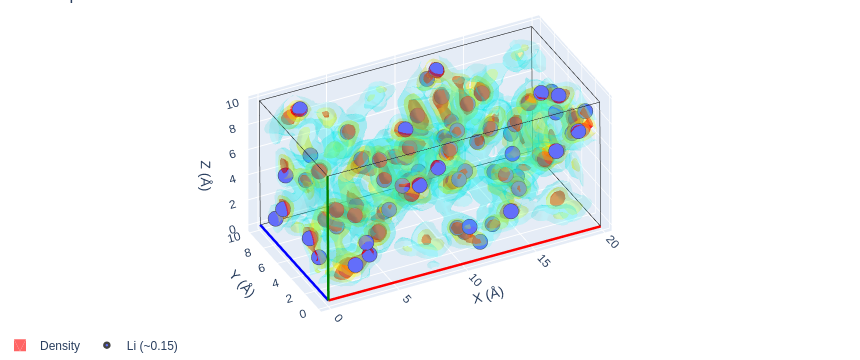

In [7]:
sites = cr_li.mobile_sites(background_level=background_level)

# Label by element only, so the plot does not give every occupancy its own colour.
for site in sites:
    site.label = 'Li'

vol = diff_trajectory.to_volume(resolution=resolution)
vol.plot_3d(structure=sites)

## Calibrating the ranking on an ideal sublattice

How much scatter is "too far"? We can find out on a structure whose symmetry we know. The
bundled `argyrodite.cif` lists the 48 ideal lithium (48*h*) sites of the conventional cell.
We build synthetic trajectories in which every lithium vibrates (0.1&nbsp;&#197;) around its
48*h* site, after first displacing that site by a random static offset of a chosen size
&mdash; a stand-in for the per-site scatter of density-derived centroids &mdash; and scan
each one.

In [8]:
from pymatgen.core import Species

from gemdat.io import load_known_material

reference = load_known_material('argyrodite')
lattice = reference.lattice
ideal = reference.frac_coords

rng = np.random.default_rng(42)


def displaced_sublattice(scatter: float, vibration: float = 0.1, n_frames: int = 200):
    """Ideal 48h Li sublattice, each site moved by a random static offset of
    rms size `scatter` (Å), with atoms vibrating around it (rms `vibration`, Å)."""
    to_frac = 1 / (np.sqrt(3) * lattice.a)
    sites = ideal + rng.normal(scale=scatter * to_frac, size=ideal.shape)
    coords = sites + rng.normal(scale=vibration * to_frac, size=(n_frames, *ideal.shape))
    return Trajectory(
        species=[Species('Li')] * len(ideal),
        coords=coords % 1,
        lattice=lattice.matrix,
        time_step=1,
        metadata={'temperature': 300},
    )


ideal_scans = {}
for scatter in (0.0, 0.1, 0.2, 0.3):
    synthetic = Crystallizer.from_trajectory(
        displaced_sublattice(scatter), floating_specie='Li', resolution=0.2
    )
    ideal_scans[scatter] = synthetic.scan(symprec_max=1.0)
    print(f'--- static scatter {scatter} Å ---')
    print(ideal_scans[scatter].format(), end='\n\n')

--- static scatter 0.0 Å ---
symprec (Å)  deviation (Å)  angle dev (°)  space group  #    crystal system  # ops  # orbits  # hits
-----------  -------------  -------------  -----------  ---  --------------  -----  --------  ------
0.01         0              0              P1           1    triclinic       1      48        23    
0.151178     0.128          0              F-43m        216  cubic           96     1         16    
1            1.259          0              Fm-3m        225  cubic           192    1         1     

--- static scatter 0.1 Å ---
symprec (Å)  deviation (Å)  angle dev (°)  space group  #    crystal system  # ops  # orbits  # hits
-----------  -------------  -------------  -----------  ---  --------------  -----  --------  ------
0.01         0              0              P1           1    triclinic       1      48        27    
0.242446     0.2387         0              Cm           8    monoclinic      2      26        4     
0.388816     0.3692         0   

Without static scatter the sublattice crystallizes straight to *F*-43*m* (#216), with all 48
sites in a single orbit. Its deviation is not zero: the density centroids of vibrating atoms
on a 0.2&nbsp;&#197; voxel grid already sit about a tenth of an &#197;ngstr&ouml;m off. Static
scatter raises the deviation *F*-43*m* needs (&#8776;0.13, 0.37 and 0.85&nbsp;&#197; for
0, 0.1 and 0.2&nbsp;&#197; of scatter), a monoclinic subgroup appears on the way up, and at
0.3&nbsp;&#197; no symmetry is left within 1&nbsp;&#197;. Note that with the default
`symprec_max` of 0.5&nbsp;&#197; the 0.2&nbsp;&#197; case would already have lost its cubic
row.

The `deviation` column also flags fits that say more about the tolerance than about the
structure: *Fm*-3*m* shows up at `symprec = 1` in the first two scans, but only by moving
atoms by more than 1.2&nbsp;&#197;.

The argyrodite framework reached *F*-43*m* at a deviation of 0.37&nbsp;&#197;, like the
sublattice with 0.1&nbsp;&#197; of scatter, while the MD lithium sites reach nothing at all
&mdash; so their centroids scatter by considerably more than that.

When the ranking does contain a group, it can be crystallized directly and written to a CIF.
[`at_spacegroup`][gemdat.crystallizer.CrystallizerScan.at_spacegroup] picks the tightest
tolerance that reaches it:

In [9]:
cubic = ideal_scans[0.1].at_spacegroup('F-43m')

print(
    f'{cubic.spacegroup_symbol} (#{cubic.spacegroup_number}) at symprec = {cubic.symprec:.3g} Å'
)
print(f'{len(cubic.structure)} sites, composition {cubic.structure.composition}')

# cubic.to_cif('argyrodite_li_F-43m.cif')

F-43m (#216) at symprec = 0.389 Å
48 sites, composition Li40.55


## Summary

For this argyrodite run the crystallizer correctly reports P1, and the ranking explains it:

- the host framework is geometrically *F*-43*m* to within ~0.37&nbsp;&#197;, but the
  S&sup2;&#8315;/Br&#8315; site disorder removes all of its symmetry;
- the lithium density sites of this short run reach no symmetry up to 1&nbsp;&#197;;
- on an ideal 48*h* sublattice the same pipeline recovers *F*-43*m*, with a deviation that
  grows with the per-site scatter until, at ~0.3&nbsp;&#197;, the cubic group drops out of
  the ranking.

A longer trajectory sharpens the lithium density, but the anion disorder is a property of
the material: recovering the textbook structure would take a model with mixed S/Br
occupancies, rather than a symmetry fit of the averaged positions.